In [5]:
import matplotlib.pyplot as plt

from knnbench.datasets import load_adult_df

In [4]:
X, y = load_adult_df()

print("Shape:", X.shape)
print("\nTarget distribution:\n")
print(y.value_counts())
print("\nColumn types:\n")
print(X.dtypes)

Shape: (48842, 14)

Target distribution:

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

Column types:

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
dtype: object


This data is from a census about income.
So as we can see above we have 1 target and 14 features (6 numeric and 8 categorical), ~49k samples, with like a 3:1 class imbalance (roughly).
meaning of all features:
1. age, just how old the person surveyed is
2. workclass, the type of employer. Think private, self-employed, government etc
3. fnlwgt, the census sampling weight (example: if 2% fnlwgt, the one person counts for 50, if 5% then 1 person counts for 20)
4. education, just the level of education. Think high school graduate, bachelor, master etc
5. education-num, the number of years in education.
6. marital-status, should be obvious. THink married, divorced etc
7. occupation, the persons job type. think sales, Tech support etc
8. relationship, similar to marital-status but this also includes stuff like having kids and stuff
9. race, could not be more obvious
10. sex, whether a person is male or female
11. capital-gain, income from investments
12. capital loss, loss from investments
13. hours-per-week, how many hours per week someone works
14. native-country, you can figure this one out yourself, i'm sure of it

In [22]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


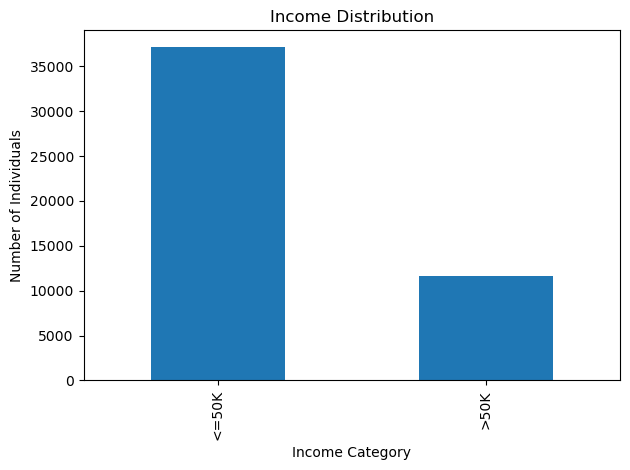

In [13]:
y.value_counts().plot(kind="bar")
plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Individuals")
plt.tight_layout()
plt.show()


Just a visualization of the class imbalance

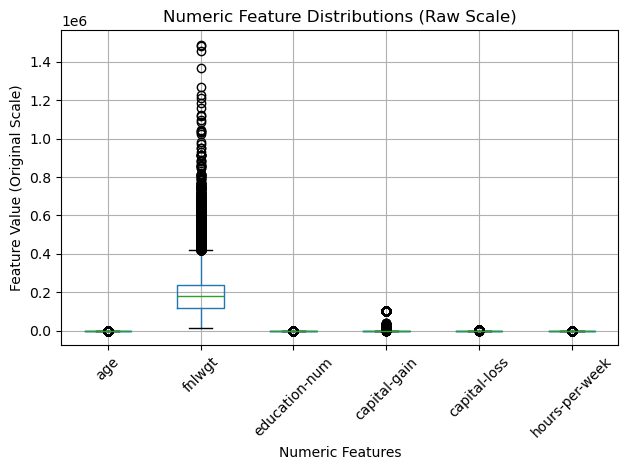

In [14]:
num_cols = X.select_dtypes(include="number").columns

X[num_cols].boxplot(rot=45)
plt.title("Numeric Feature Distributions (Raw Scale)")
plt.xlabel("Numeric Features")
plt.ylabel("Feature Value (Original Scale)")
plt.tight_layout()
plt.show()

The above shows the scale of the different numeric features, as we can see, they do in fact operate on different scales. (this basically just means that for example some oculd be counted in the tens or hundreds, whilst others are counted in ones) So since kNN is based on distance, scaling our numerical features is going to be really important to performance.

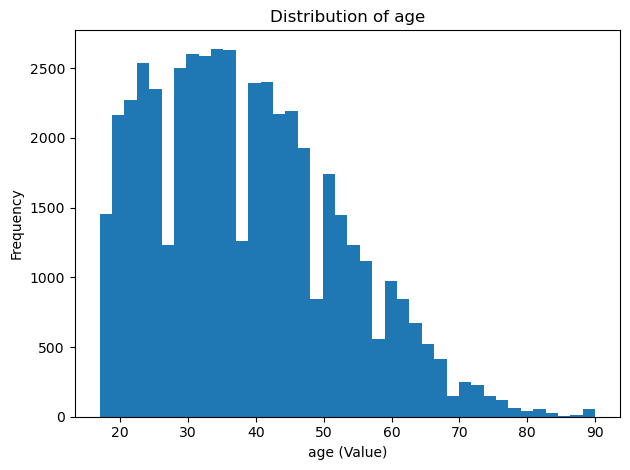

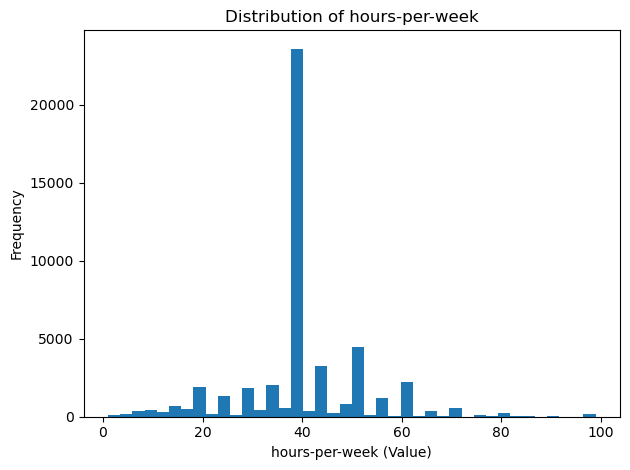

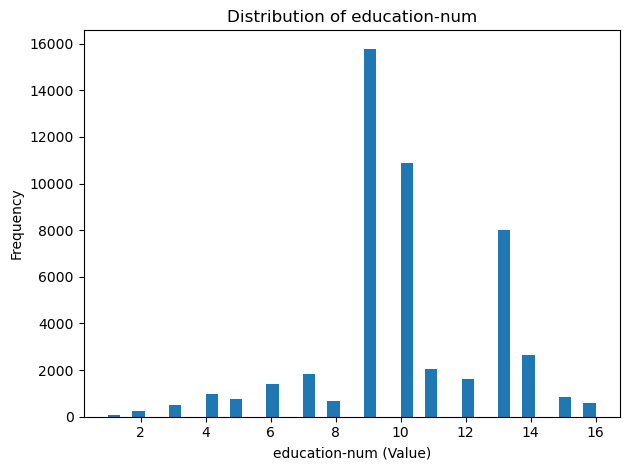

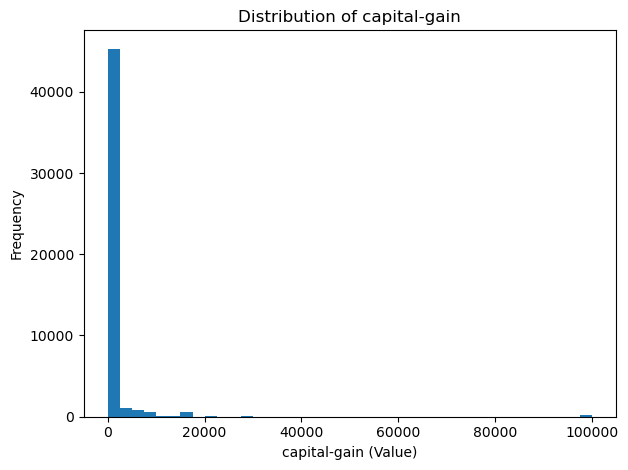

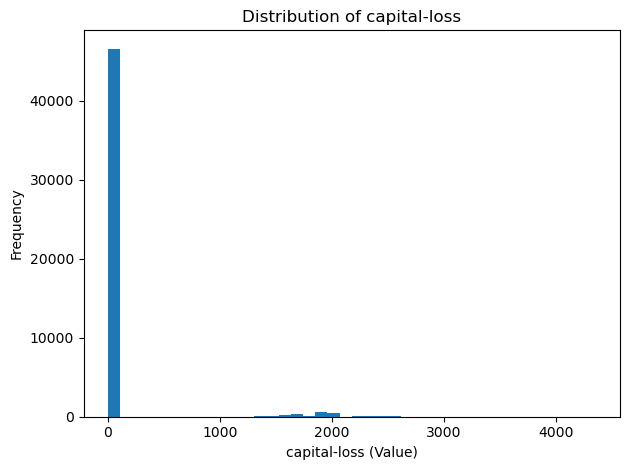

In [15]:
for col in ["age", "hours-per-week", "education-num", "capital-gain", "capital-loss"]:
    plt.figure()
    plt.hist(X[col].dropna(), bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(f"{col} (Value)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

showcase of the more important numerical features (so just all of them except for fnlwgt or whatever it was):
y-axis is amount of people, x-axis depends on the feature

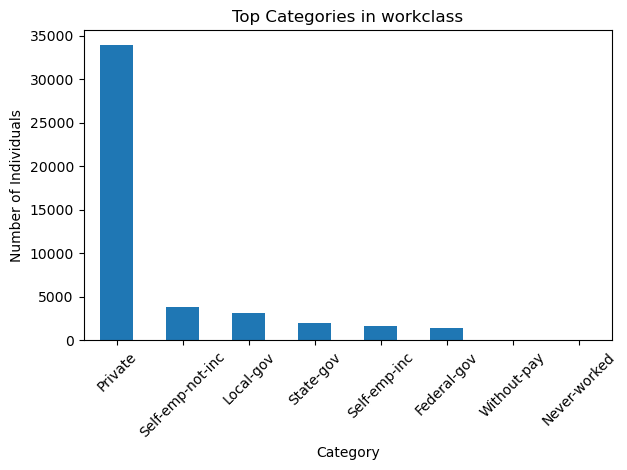

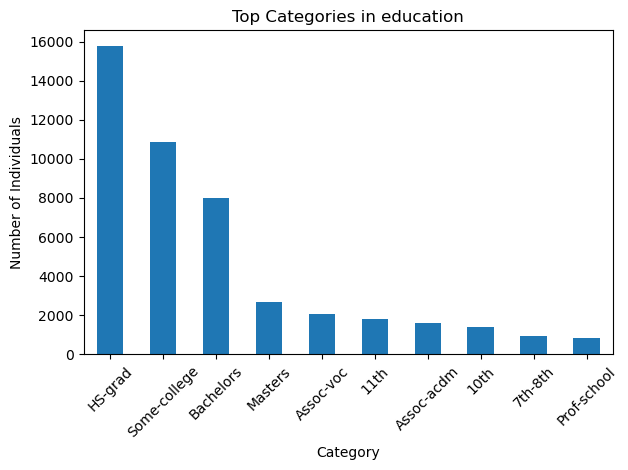

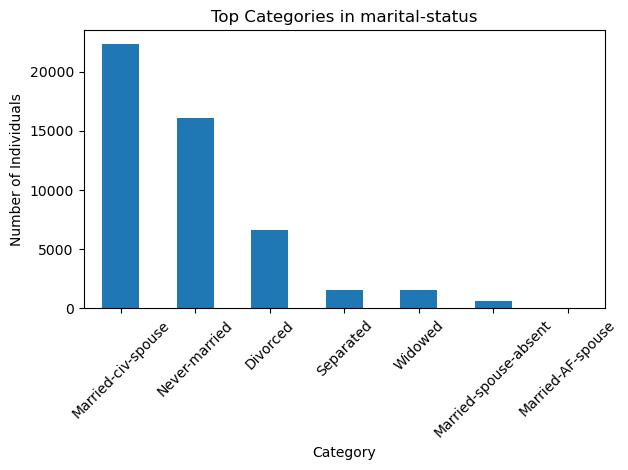

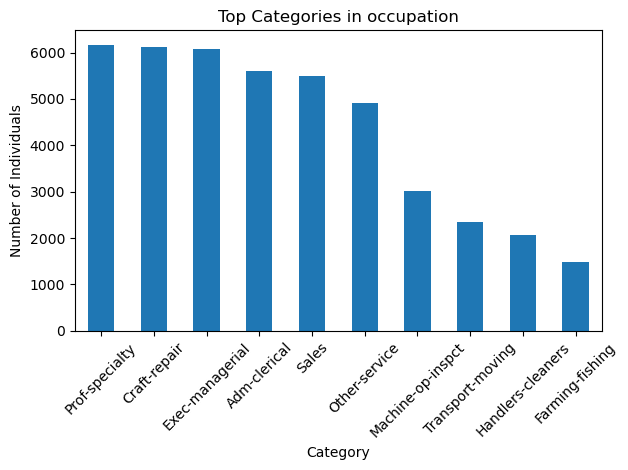

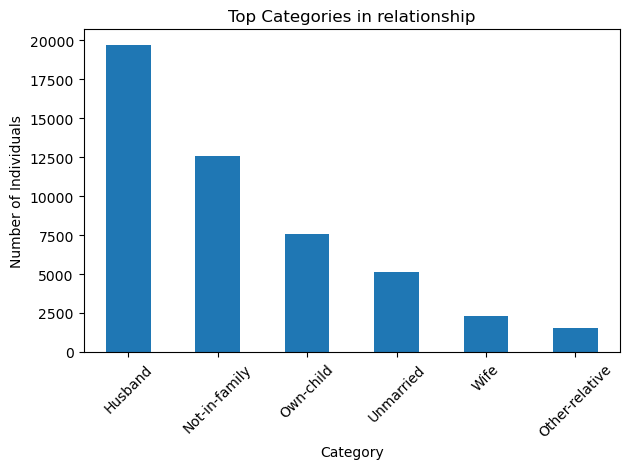

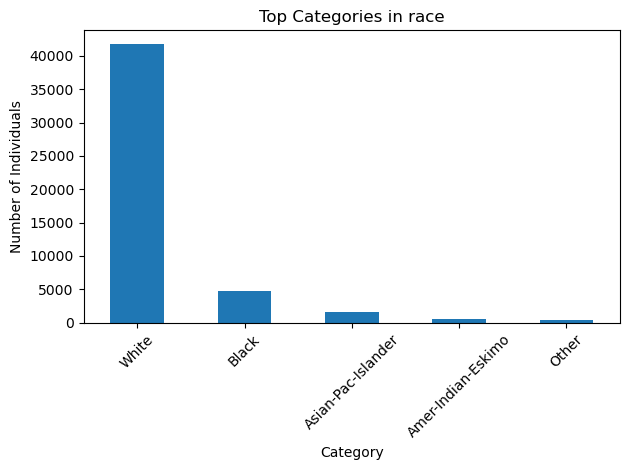

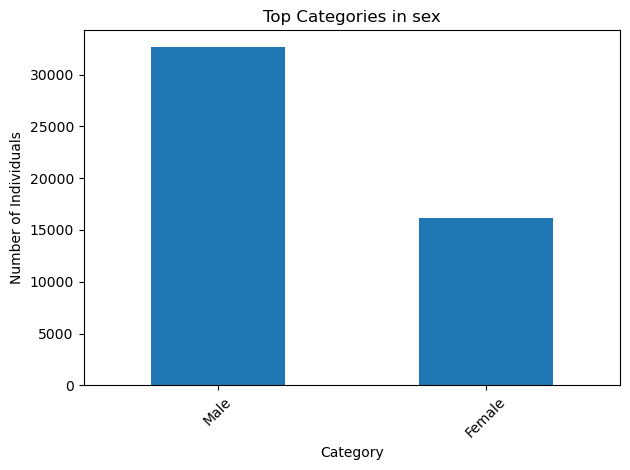

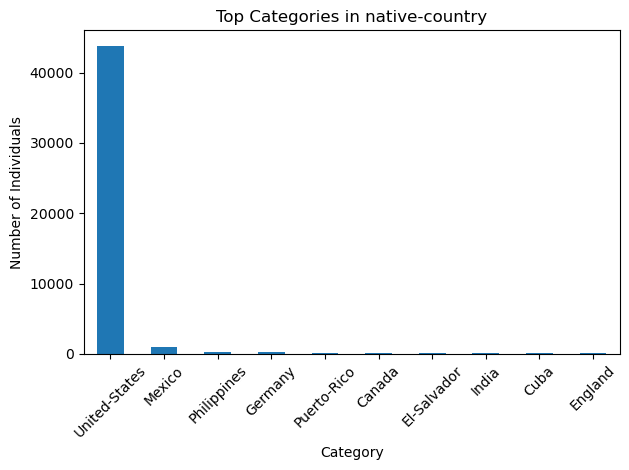

In [16]:
for col in ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]:
    plt.figure()
    X[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top Categories in {col}")
    plt.xlabel("Category")
    plt.ylabel("Number of Individuals")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Just a showcase of all the categorical features, not much more to say about that.

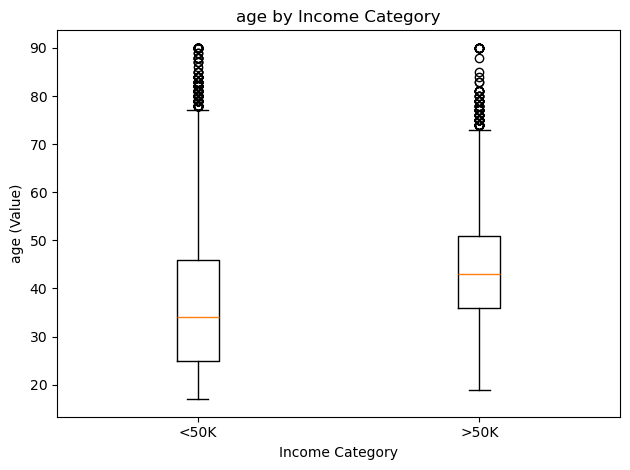

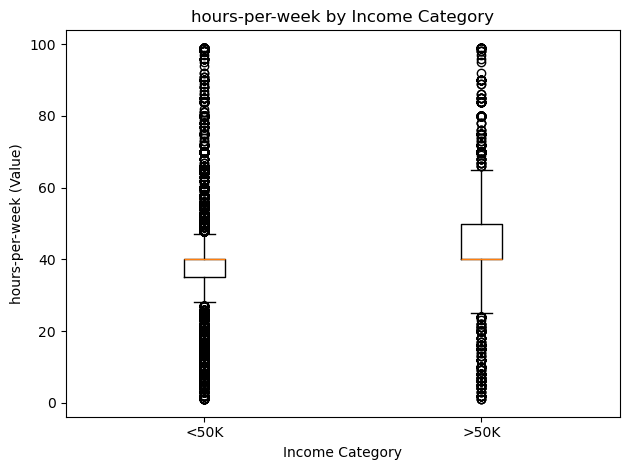

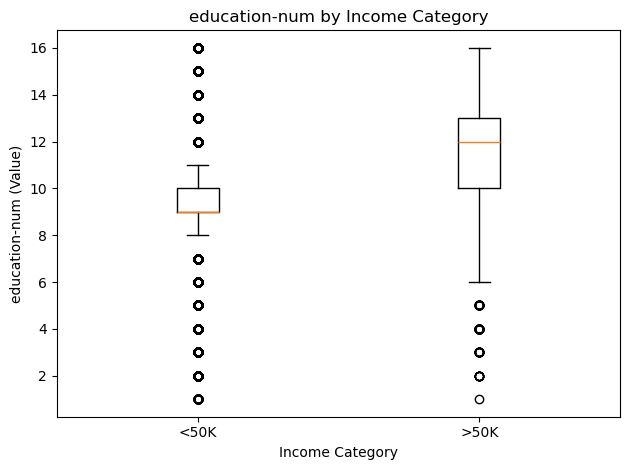

In [21]:
plot_df = X.copy()
plot_df["income"] = y

for col in ["age", "hours-per-week", "education-num"]:
    data0 = plot_df[plot_df["income"].str.contains("<=50K")][col]
    data1 = plot_df[plot_df["income"].str.contains(">50K")][col]

    plt.figure()
    plt.boxplot([data0, data1], tick_labels=["<50K", ">50K"])
    plt.title(f"{col} by Income Category")
    plt.xlabel("Income Category")
    plt.ylabel(f"{col} (Value)")
    plt.tight_layout()
    plt.show()

some box plots for age, hours worked and time in education, we can basically see that if you are older, work more hours or have spent more time in education, you have higher chance of being someone that is earning more thank 50k. It is not saying that these things cause you to earn over 50k, but it is saying that if you earn more than 50k, you are more like to be doing those things.